# Figure gallery

All exported figures in `figures/`, shown in a grid. The gallery is built by
globbing the folder at run time, so every figure currently in `figures/` is
included automatically. Re-run this notebook after regenerating figures to
refresh it.

## Imports

In [1]:
import base64
from datetime import datetime
from pathlib import Path

from IPython.display import HTML, display

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Gallery

Images are base64-embedded so the page is self-contained and the paths resolve
in the built book.

Found 4 figure(s) in ..\figures



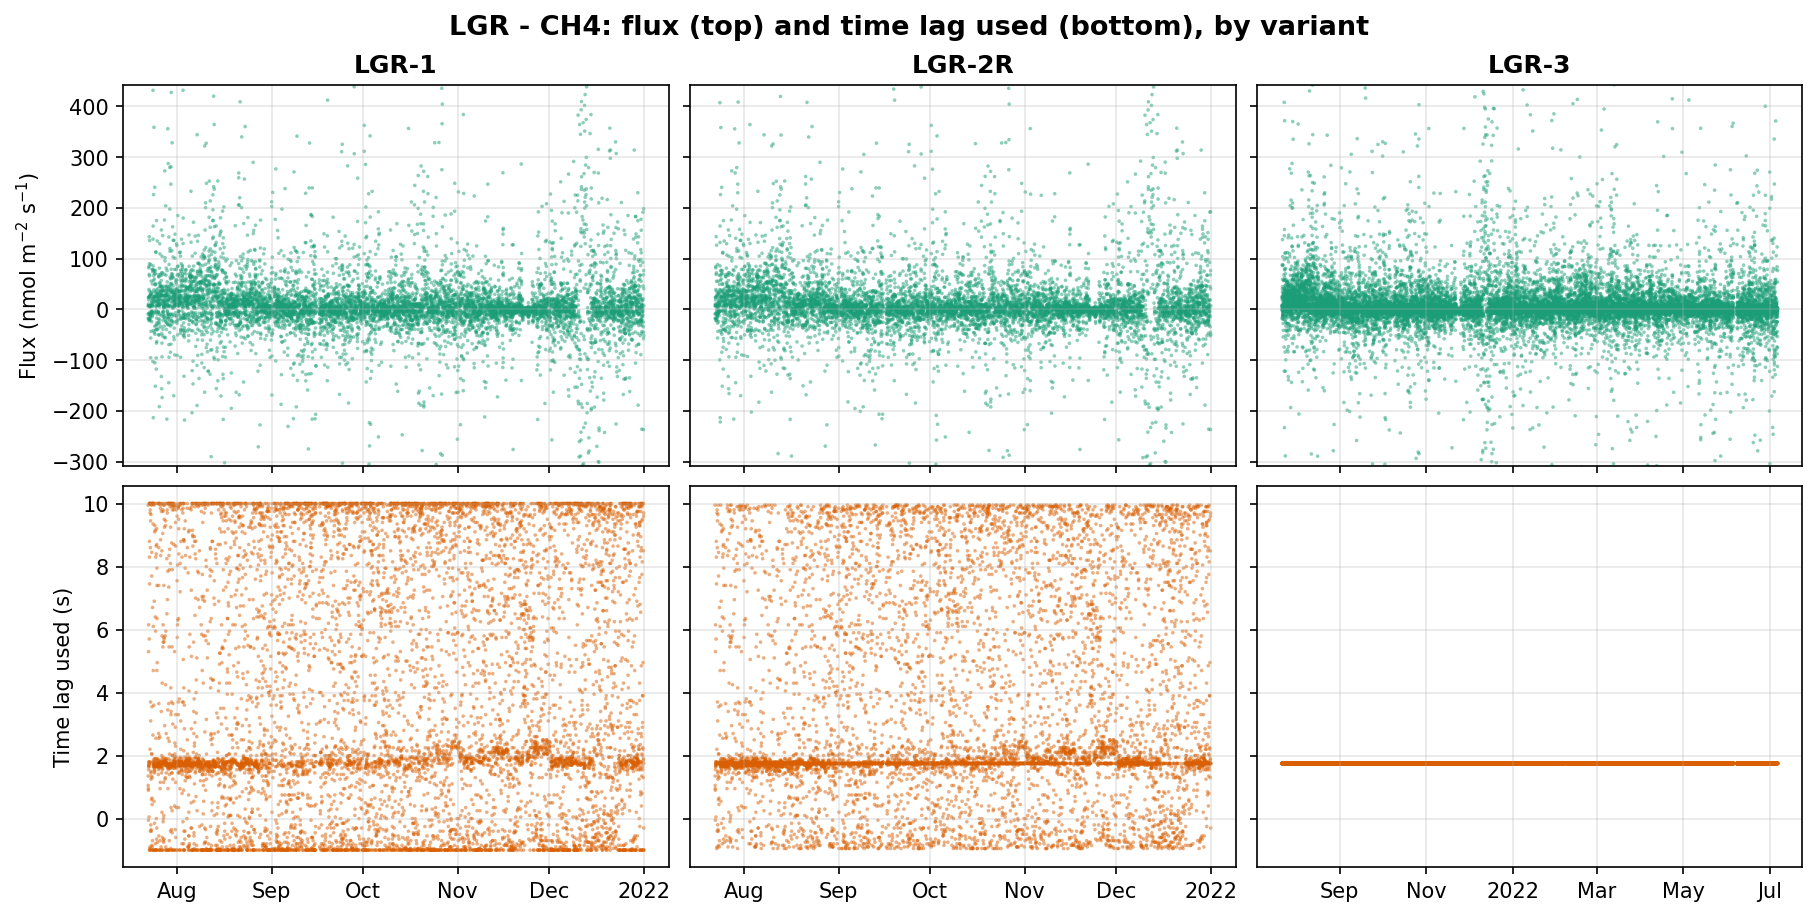
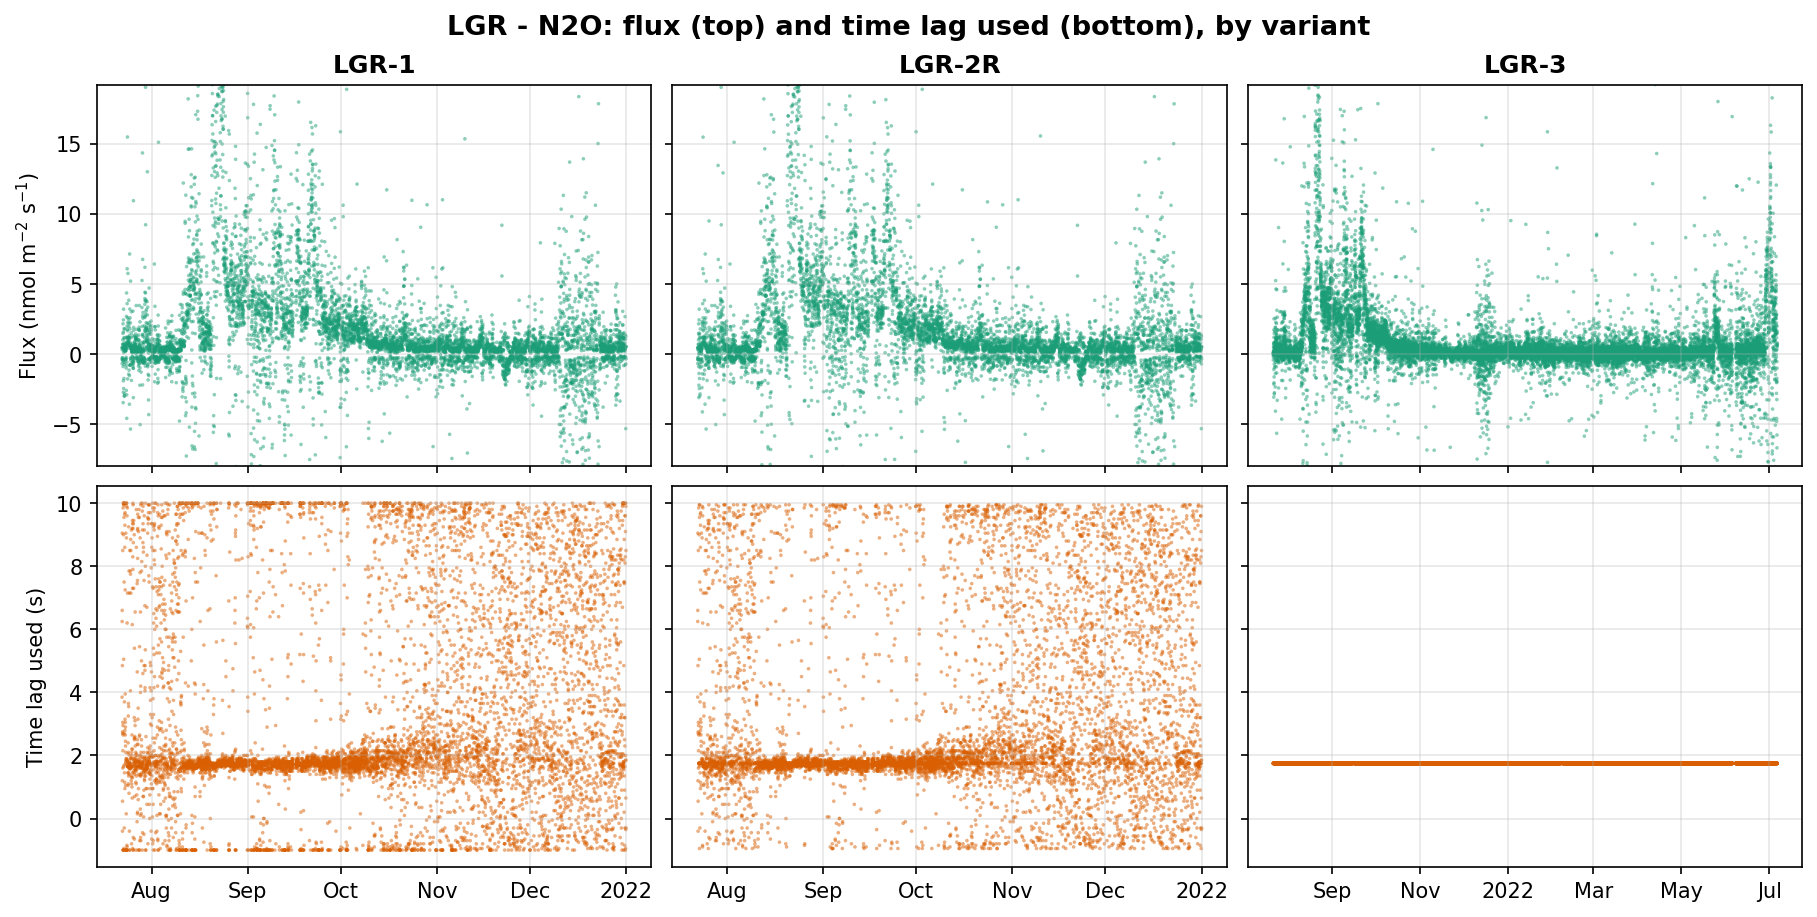
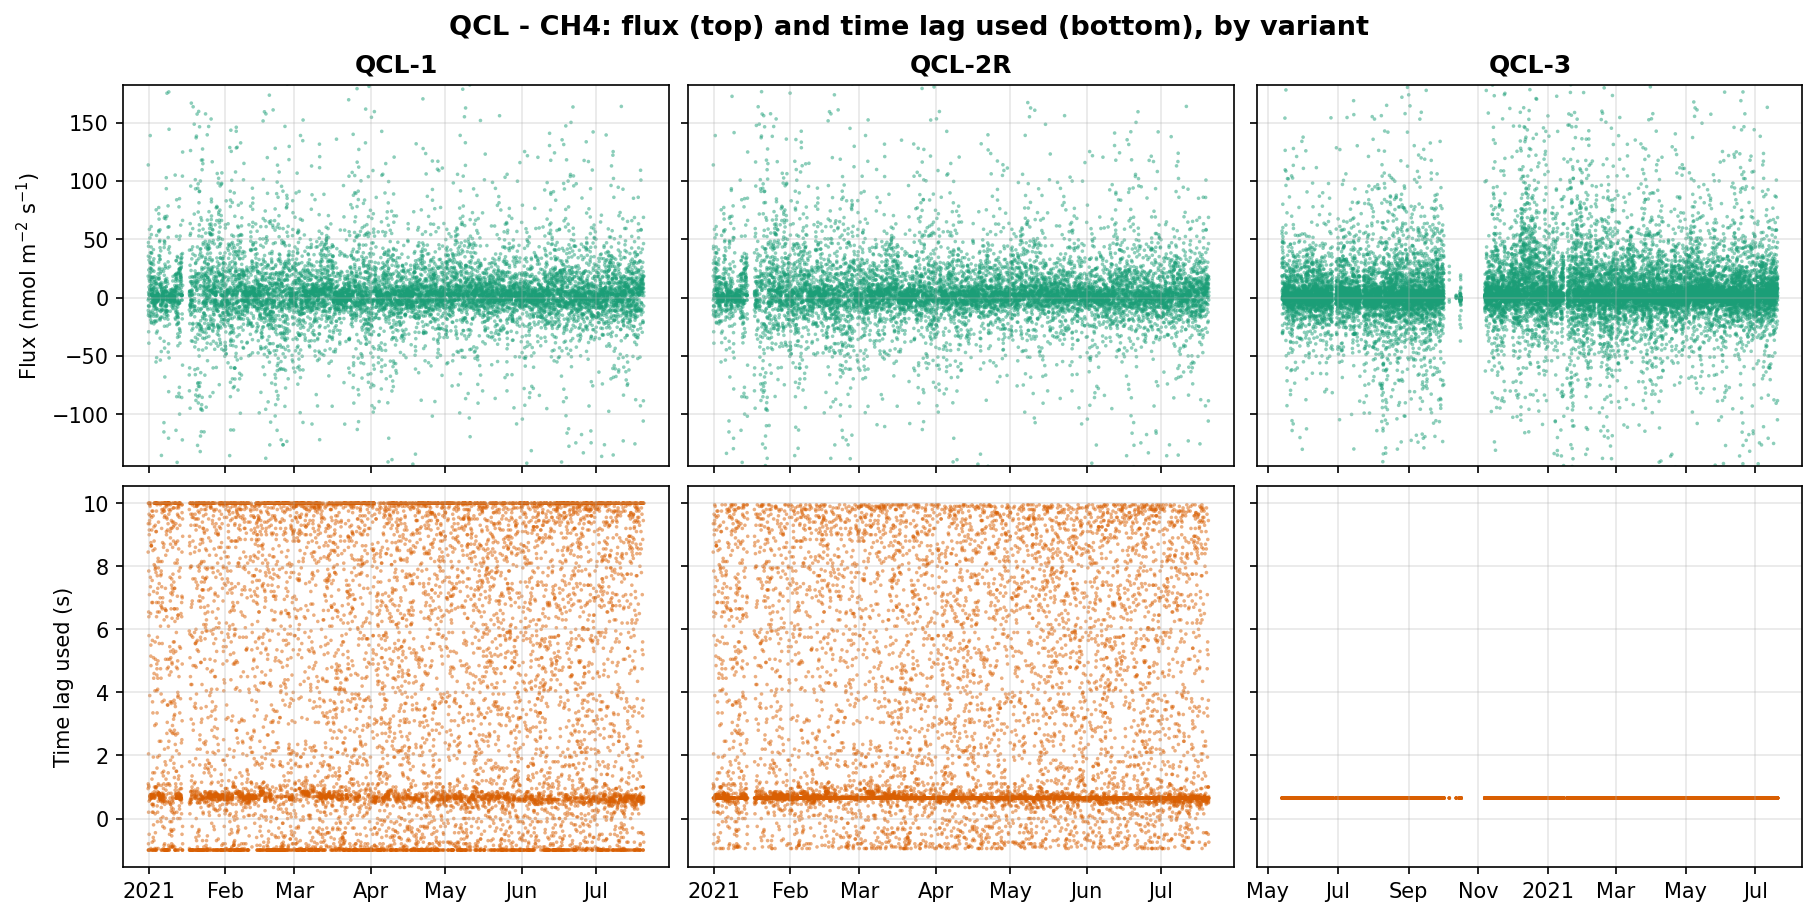
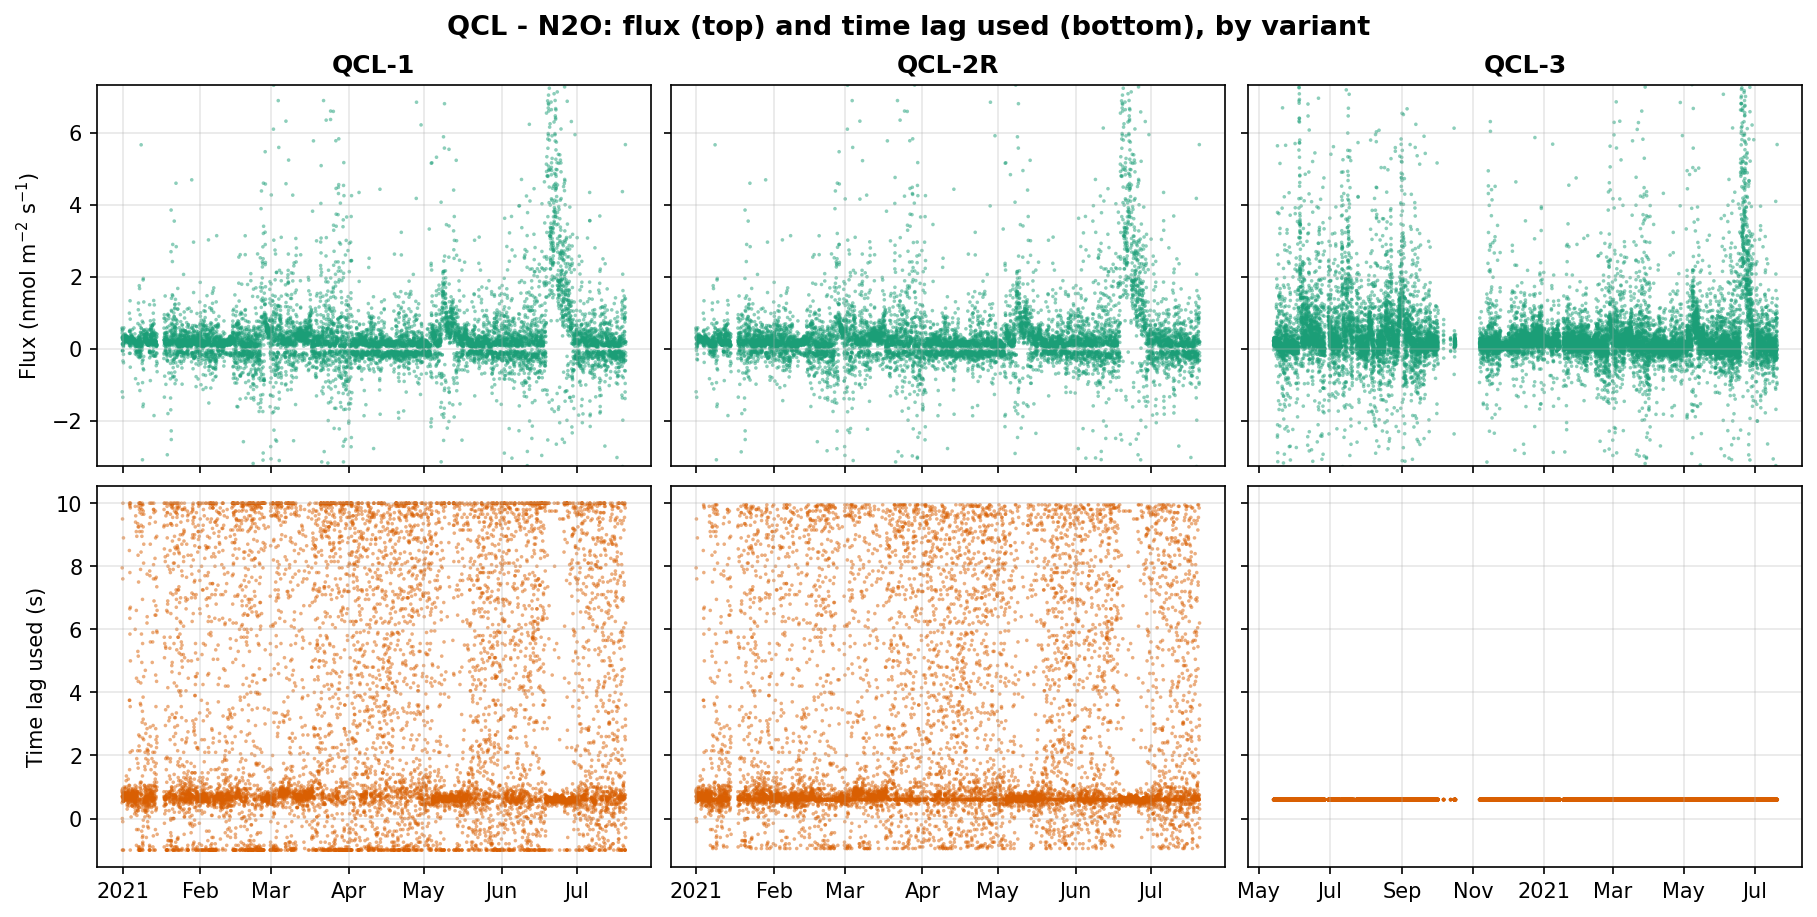

In [2]:
FIGDIR = Path("../figures")
EXTS = ("*.png", "*.jpg", "*.jpeg", "*.gif", "*.svg")

images = sorted(p for ext in EXTS for p in FIGDIR.glob(ext))
print(f"Found {len(images)} figure(s) in {FIGDIR}")

MIME = {".png": "image/png", ".jpg": "image/jpeg", ".jpeg": "image/jpeg",
        ".gif": "image/gif", ".svg": "image/svg+xml"}

cards = []
for p in images:
    b64 = base64.b64encode(p.read_bytes()).decode()
    mime = MIME.get(p.suffix.lower(), "image/png")
    cards.append(
        '<figure style="margin:0">'
        f'<img src="data:{mime};base64,{b64}" '
        'style="width:100%;height:auto;border:1px solid #ccc;border-radius:4px"/>'
        f'<figcaption style="font-size:0.8em;text-align:center;word-break:break-all">{p.name}</figcaption>'
        '</figure>'
    )

if cards:
    grid = (
        '<div style="display:grid;'
        'grid-template-columns:repeat(auto-fill,minmax(320px,1fr));gap:1rem">'
        + "".join(cards) + "</div>"
    )
    display(HTML(grid))
else:
    print("No figures found yet. Run the plotting notebooks first.")

## Runtime

In [3]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-04 17:52:55
End:      2026-06-04 17:52:57
Runtime:  0:00:01.510963
